# CDNMF — Contrastive Deep NMF for Community Detection

Paper: [Contrastive Deep Nonnegative Matrix Factorization for Community Detection](https://arxiv.org/abs/2311.02357) (ICASSP 2024)



## 1. Setup (fixed path — no nested folders)

In [8]:
#@title Clone repo into /content/CDNMF (safe)
import os, sys
from pathlib import Path

ROOT = Path('/content/CDNMF')

# Always work from a single clean clone location
os.chdir('/content')
if not (ROOT / 'Model' / 'my_model.py').exists():
    # Remove broken nested leftovers if present
    if ROOT.exists() and not (ROOT / 'Model' / 'my_model.py').exists():
        import shutil
        shutil.rmtree(ROOT)
    !git clone https://github.com/6lyc/CDNMF.git /content/CDNMF

os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print('CWD:', os.getcwd())
print('Has model:', (ROOT / 'Model' / 'my_model.py').exists())
print('Has cora features:', (ROOT / 'Database' / 'cora' / 'features.txt').exists())
print('Has cora pretrain:', (ROOT / 'Log' / 'cora' / 'pretrain_params.pkl').exists())

!pip install -q numpy scipy scikit-learn tqdm matplotlib networkx

import torch
print('torch:', torch.__version__, '| CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

CWD: /content/CDNMF
Has model: True
Has cora features: True
Has cora pretrain: True
torch: 2.11.0+cu128 | CUDA: True
GPU: Tesla T4


In [9]:
#@title Patch missing walks.txt (citeseer/pubmed)
from pathlib import Path

for name in ['citeseer', 'pubmed', 'wiki']:
    p = Path(f'Database/{name}/walks.txt')
    if not p.exists():
        p.parent.mkdir(parents=True, exist_ok=True)
        p.write_text('')
        print('Created empty', p)

# Make walks optional in Dataset loader
dataset_py = Path('Dataset/dataset.py')
text = dataset_py.read_text()
if "config.get('walks_file'" not in text:
    text = text.replace(
        "self.walks_file = config['walks_file']",
        "self.walks_file = config.get('walks_file', None)",
    )
    text = text.replace(
        "lines = linecache.getlines(self.walks_file)",
        "lines = linecache.getlines(self.walks_file) if self.walks_file else []",
        1,
    )
    # Only the walks block should be guarded; simplest: empty file already created
    dataset_py.write_text(text)
    print('Patched walks_file to optional')
else:
    print('Dataset walks already optional / OK')

Dataset walks already optional / OK


## 2. Choose run mode

| Mode | What it does | Use for |
|------|----------------|---------|
| `smoke` | 1 run × 30 epochs | only check GPU works |
| `project` | **1 run × 550 epochs** | **your Project 1 slides** |
| `paper` | 20 runs × 550 epochs | full Table 1 average (slow) |

In [10]:
#@title Config
DATASET = 'cora'  #@param ['cora', 'citeseer', 'pubmed']
RUN_MODE = 'paper'  #@param ['smoke', 'project', 'paper']
FORCE_PRETRAIN = False  #@param {type: 'boolean'}

PAPER_CFG = {
    'cora': {
        'net_shape': [1000, 500, 7],
        'att_shape': [500, 200, 7],
        'tau': 1.3, 'conc': 5, 'negc': 400, 'rec': 1, 'r': 3,
        'learning_rate': 0.01, 'epoch': 550, 'run': 20,
    },
    'citeseer': {
        'net_shape': [256, 64, 6],
        'att_shape': [500, 100, 6],
        'tau': 1.5, 'conc': 5, 'negc': 3000, 'rec': 1, 'r': 1,
        'learning_rate': 0.001, 'epoch': 1000, 'run': 20,
    },
    'pubmed': {
        'net_shape': [512, 64, 3],
        'att_shape': [200, 100, 3],
        'tau': 0.5, 'conc': 1, 'negc': 100, 'rec': 1, 'r': 1,
        'learning_rate': 0.01, 'epoch': 600, 'run': 20,
    },
}

cfg = dict(PAPER_CFG[DATASET])
if RUN_MODE == 'smoke':
    cfg['epoch'], cfg['run'] = 30, 1
elif RUN_MODE == 'project':
    cfg['epoch'], cfg['run'] = cfg['epoch'], 1   # full epochs, 1 run (good for slides)
elif RUN_MODE == 'paper':
    pass  # keep 20 runs

print(f'Mode={RUN_MODE} | Dataset={DATASET} | runs={cfg["run"]} | epochs={cfg["epoch"]}')
print('Paper Cora target: ACC≈0.6081, NMI≈0.4006')

Mode=paper | Dataset=cora | runs=20 | epochs=550
Paper Cora target: ACC≈0.6081, NMI≈0.4006


## 3. Load data

In [11]:
import os, random, numpy as np, torch
from time import perf_counter as t
import matplotlib.pyplot as plt

from Dataset.dataset import Dataset
from Model.my_model import Model
from PreTrainer.pretrainer import PreTrainer
from Utils.evaluate import clusterscores

random.seed(42); np.random.seed(42); torch.manual_seed(42)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('device:', device)

os.makedirs(f'Log/{DATASET}', exist_ok=True)

graph = Dataset({
    'feature_file': f'./Database/{DATASET}/features.txt',
    'graph_file': f'./Database/{DATASET}/edges.txt',
    'walks_file': f'./Database/{DATASET}/walks.txt',
    'label_file': f'./Database/{DATASET}/group.txt',
    'device': device,
})
print('num classes r =', graph.num_classes)

device: cuda:0
nodes 2708, edes 5278.0, features 1433, classes 7
num classes r = 7


## 4. Pre-training

If init ACC (next section) is very low (&lt;0.40 on Cora), re-run this cell with `FORCE_PRETRAIN=True` in the config cell.

In [12]:
pretrain_path = f'./Log/{DATASET}/pretrain_params.pkl'

pretrain_config = {
    'net_shape': cfg['net_shape'],
    'att_shape': cfg['att_shape'],
    'net_input_dim': graph.num_nodes,
    'att_input_dim': graph.num_feas,
    'seed': 42,
    'pre_iterations': 100,
    'pretrain_params_path': pretrain_path,
}

need = FORCE_PRETRAIN or (not os.path.isfile(pretrain_path)) or os.path.getsize(pretrain_path) < 10000
if need:
    print('Running layer-wise NMF pre-training (can take several minutes)...')
    pretrainer = PreTrainer(pretrain_config)
    pretrainer.pre_training(graph.A.detach().cpu().numpy(), 'net')
    pretrainer.pre_training(graph.X.t().detach().cpu().numpy(), 'att')
    print('Saved', pretrain_path, 'size=', os.path.getsize(pretrain_path))
else:
    print('Using existing pretrain:', pretrain_path, 'size=', os.path.getsize(pretrain_path))

Using existing pretrain: ./Log/cora/pretrain_params.pkl size= 40100248


## 5. Fine-tuning + curves (for Slide 4)

In [13]:
def eval_now(model, graph):
    with torch.no_grad():
        V = model()
        pred = np.argmax(V.detach().cpu().numpy(), axis=0)
        true = graph.L.detach().cpu().numpy()
        return clusterscores(pred, true)


model_config = {
    'device': device,
    'net_shape': cfg['net_shape'],
    'att_shape': cfg['att_shape'],
    'net_input_dim': graph.num_nodes,
    'att_input_dim': graph.num_feas,
    'is_init': True,
    'pretrain_params_path': pretrain_path,
    'tau': cfg['tau'],
    'conc': cfg['conc'],
    'negc': cfg['negc'],
    'rec': cfg['rec'],
    'r': cfg['r'],
    'model_path': f'./Log/{DATASET}/{DATASET}_model.pkl',
}

# ---- sanity check: ACC right after loading pretrain (before fine-tune) ----
probe = Model(model_config).to(device)
init_scores = eval_now(probe, graph)
print(f'Init (pretrained only) ACC={init_scores["ACC"]:.4f} NMI={init_scores["NMI"]:.4f}')
if DATASET == 'cora' and init_scores['ACC'] < 0.40:
    print('WARNING: init ACC is low. Set FORCE_PRETRAIN=True, re-run config + pretrain + this cell.')

acc_runs, nmi_runs = [], []
history = {'epoch': [], 'loss': [], 'ACC': [], 'NMI': []}  # last run curves
start = t()

for run in range(cfg['run']):
    model = Model(model_config).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['learning_rate'])

    for epoch in range(1, cfg['epoch'] + 1):
        optimizer.zero_grad()
        V = model()
        loss, *_ = model.loss(graph)
        loss.backward()
        optimizer.step()

        scores = eval_now(model, graph)

        if run == cfg['run'] - 1:
            history['epoch'].append(epoch)
            history['loss'].append(loss.item())
            history['ACC'].append(scores['ACC'])
            history['NMI'].append(scores['NMI'])

        if epoch == 1 or epoch % 50 == 0 or epoch == cfg['epoch']:
            print(
                f"[run {run+1}/{cfg['run']}] epoch {epoch:4d} | "
                f"loss={loss.item():.2f} | ACC={scores['ACC']:.4f} | NMI={scores['NMI']:.4f}"
            )

    acc_runs.append(scores['ACC'])
    nmi_runs.append(scores['NMI'])

print('=' * 60)
print(f'Dataset: {DATASET} | mode: {RUN_MODE}')
print(f'ACC: {np.mean(acc_runs):.4f} ± {np.std(acc_runs):.4f}')
print(f'NMI: {np.mean(nmi_runs):.4f} ± {np.std(nmi_runs):.4f}')
print(f'Time: {t()-start:.1f}s')
print('Paper Table 1 Cora: ACC=0.6081 | NMI=0.4006')
print('=' * 60)

Init (pretrained only) ACC=0.3239 NMI=0.1293
[run 1/20] epoch    1 | loss=19346.69 | ACC=0.3176 | NMI=0.1225
[run 1/20] epoch   50 | loss=17072.53 | ACC=0.3637 | NMI=0.1295
[run 1/20] epoch  100 | loss=15745.90 | ACC=0.4298 | NMI=0.2273
[run 1/20] epoch  150 | loss=15044.72 | ACC=0.4742 | NMI=0.2774
[run 1/20] epoch  200 | loss=14641.64 | ACC=0.5066 | NMI=0.2934
[run 1/20] epoch  250 | loss=14273.24 | ACC=0.5325 | NMI=0.3178
[run 1/20] epoch  300 | loss=14026.32 | ACC=0.5454 | NMI=0.3304
[run 1/20] epoch  350 | loss=13842.48 | ACC=0.5668 | NMI=0.3465
[run 1/20] epoch  400 | loss=13699.13 | ACC=0.5801 | NMI=0.3575
[run 1/20] epoch  450 | loss=13583.15 | ACC=0.5883 | NMI=0.3707
[run 1/20] epoch  500 | loss=13486.00 | ACC=0.5975 | NMI=0.3921
[run 1/20] epoch  550 | loss=13402.01 | ACC=0.5979 | NMI=0.4017
[run 2/20] epoch    1 | loss=19346.68 | ACC=0.3383 | NMI=0.1382
[run 2/20] epoch   50 | loss=17062.70 | ACC=0.3612 | NMI=0.1003
[run 2/20] epoch  100 | loss=15738.12 | ACC=0.4465 | NMI=0.

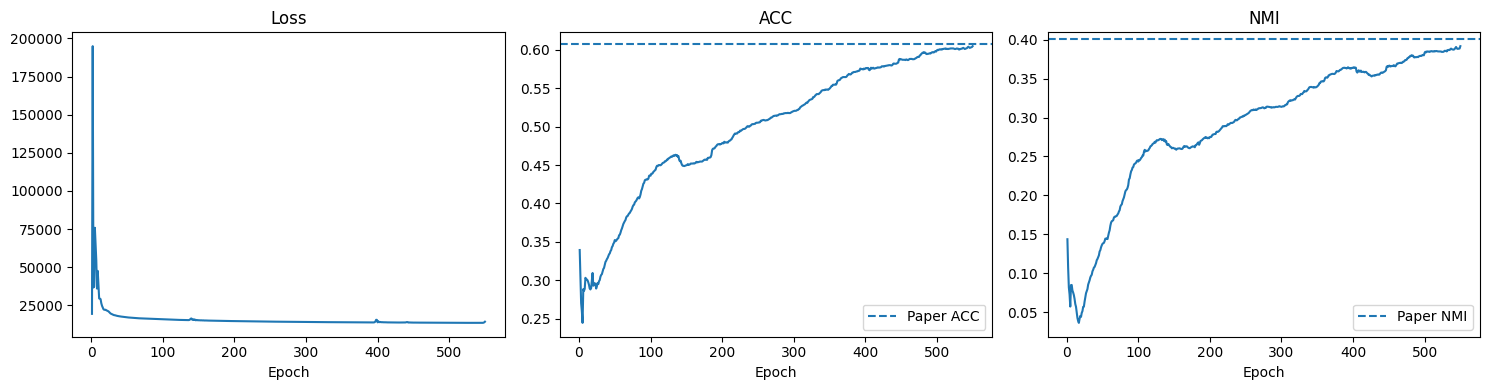

Saved figure: Log/cora/curves_paper.png


,Setting,ACC,NMI
0,Original paper (Table 1),0.608100,0.400600
1,Our reproduction (paper),0.600609,0.394161


Download Log/cora/curves_*.png and comparison_*.csv for your slides


In [14]:
#@title Plot curves for Slide 4
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['epoch'], history['loss'])
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')

axes[1].plot(history['epoch'], history['ACC'])
axes[1].axhline(0.6081, ls='--', label='Paper ACC')
axes[1].set_title('ACC'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(history['epoch'], history['NMI'])
axes[2].axhline(0.4006, ls='--', label='Paper NMI')
axes[2].set_title('NMI'); axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.tight_layout()
fig_path = f'Log/{DATASET}/curves_{RUN_MODE}.png'
plt.savefig(fig_path, dpi=150)
plt.show()
print('Saved figure:', fig_path)

# Comparison table for slides
import pandas as pd
paper = {'cora': (0.6081, 0.4006), 'citeseer': (0.4756, 0.2559), 'pubmed': (0.6653, 0.2330)}
p_acc, p_nmi = paper[DATASET]
df = pd.DataFrame([
    {'Setting': 'Original paper (Table 1)', 'ACC': p_acc, 'NMI': p_nmi},
    {'Setting': f'Our reproduction ({RUN_MODE})', 'ACC': float(np.mean(acc_runs)), 'NMI': float(np.mean(nmi_runs))},
])
display(df)
df.to_csv(f'Log/{DATASET}/comparison_{RUN_MODE}.csv', index=False)
print('Download Log/{}/curves_*.png and comparison_*.csv for your slides'.format(DATASET))